In [1]:
import sys

import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob

sys.path.append('/home/mi58rip/gr-athena/vis/python/')

import athena_read
import yaaps

from yaaps import simulation
from yaaps.simulation import Simulation
import yaaps.plot2D as yp

In [18]:
# OUTPUT_DIR = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/'

# data = np.loadtxt(OUTPUT_DIR + 'gr_rns.hst', comments='#')

# fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# times = data[:, 0]
# print("No of snapshots:", len(times))

# # Convert time to milliseconds
# times = times * 4.925490947e-6 * 1000

# mass = data[:, 3]
# max_rhos = data[:, 20]

# ax[0].plot(times, mass, color='darkgreen')
# ax[0].set_xlabel('Time (ms)', fontsize=12)
# ax[0].set_ylabel(r'$M_{\rm bar}$', fontsize=12)
# ax[0].set_title('Barionic Mass', fontsize=14)
# # ax[0].set_yscale('log')
# # ax[0].set_xscale('log')
# ax[0].grid(True, linestyle='--', alpha=0.7)

# ax[1].plot(times, max_rhos, color='navy')
# ax[1].set_xlabel('Time (ms)', fontsize=12)
# ax[1].set_ylabel(r'$\rho_{\rm max}$', fontsize=12)
# ax[1].set_title('Max Density', fontsize=14)
# ax[1].set_yscale('log')
# ax[1].set_xscale('log')
# ax[1].grid(True, linestyle='--', alpha=0.7)
# ax[1].axhline(y=max_rhos[0], color='red', linestyle='--', label=r'$\rho_{\rm max}\left(t=0\right)$')
# ax[1].legend()

# # Title
# fig.suptitle('RNS Test SFHo (.hst)', fontsize=12)

# plt.tight_layout()
# plt.savefig(OUTPUT_DIR + 'gr_rns_hst_mass_rho.pdf', dpi=600)
# plt.show()

No of snapshots: 2301


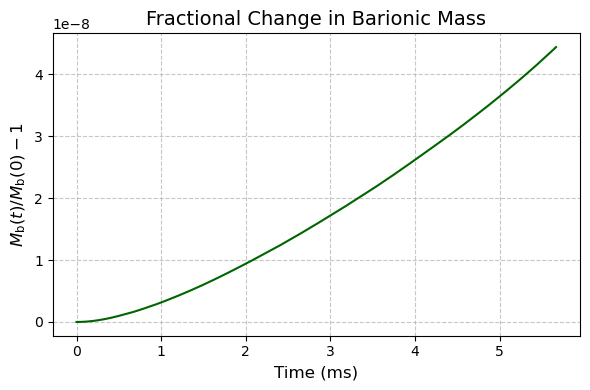

In [39]:
OUTPUT_DIR = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/'
PLOTS_DIR = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/diagnostics/'

data = np.loadtxt(OUTPUT_DIR + 'gr_rns.hst', comments='#')

fig, ax = plt.subplots(figsize=(6, 4))

times = data[:, 0]
print("No of snapshots:", len(times))

# Convert time to milliseconds
times = times * 4.925490947e-6 * 1000

mass = data[:, 3]

normalised_mass = (mass) / mass[0]
ax.plot(times, normalised_mass - 1.0, color='darkgreen')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel(r'$M_{\rm b} \left(t\right) / M_{\rm b}\left(0\right) - 1$', fontsize=12)
ax.set_title('Fractional Change in Barionic Mass', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'gr_rns_frac_change_bar_mass.pdf', dpi=600)
plt.show()

No of snapshots: 2306


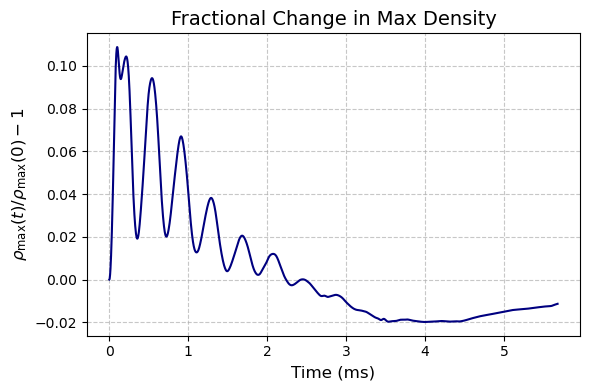

In [40]:
OUTPUT_DIR = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/'
PLOTS_DIR = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/diagnostics/'

data = np.loadtxt(OUTPUT_DIR + 'gr_rns.hst', comments='#')

fig, ax = plt.subplots(figsize=(6, 4))

times = data[:, 0]
print("No of snapshots:", len(times))

# Convert time to milliseconds
times = times * 4.925490947e-6 * 1000

max_rhos = data[:, 20]

normalised_rho = (max_rhos) / max_rhos[0]


ax.plot(times, normalised_rho - 1.0, color='navy')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel(r'$\rho_{\rm max} \left(t\right) / \rho_{\rm max}\left(0\right) - 1$', fontsize=12)
ax.set_title('Fractional Change in Max Density', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)
# ax.axhline(y=0, color='red', linestyle='--', label=r'$\Delta \rho_{\rm max} / \rho_{\rm max}\left(t=0\right) = 0$')
# ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'gr_rns_frac_change_rho_max.pdf', dpi=600)
plt.show()


In [43]:
def print_hdf5_structure(name, obj):
    print(name)
    if isinstance(obj, h5py.Dataset):
        print(f"  Dataset shape: {obj.shape}, dtype: {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print("  Group")

In [53]:
filepath = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/gr_rns.out3.00000.athdf'

with h5py.File(filepath, 'r') as f:
    # Athena++ stores variable names as an attribute of the root file
    var_names = f.attrs['VariableNames']
    
    # Decode the byte strings to readable text
    names = [name.decode('utf-8') if isinstance(name, bytes) else name for name in var_names]
    
    print("The 20 variables in the 'hydro' dataset are:")
    for i, name in enumerate(names):
        print(f"Index {i}: {name}")

The 20 variables in the 'hydro' dataset are:
Index 0: hydro.cons.D
Index 1: hydro.cons.S_d_1
Index 2: hydro.cons.S_d_2
Index 3: hydro.cons.S_d_3
Index 4: hydro.cons.tau
Index 5: hydro.prim.rho
Index 6: hydro.prim.util_u_1
Index 7: hydro.prim.util_u_2
Index 8: hydro.prim.util_u_3
Index 9: hydro.prim.p
Index 10: hydro.aux.c2p_status
Index 11: hydro.aux.W
Index 12: hydro.aux.T
Index 13: hydro.aux.h
Index 14: hydro.aux.s
Index 15: hydro.aux.e
Index 16: hydro.aux.u_t
Index 17: hydro.aux.hu_t
Index 18: hydro.aux.cs2
Index 19: hydro.aux.Omega


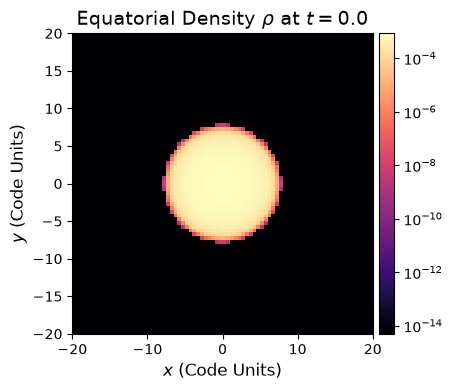

In [26]:
sim = Simulation("/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR", 
                 input_path="/home/mi58rip/gr-athena/runs/rns_test_SFHo/gr_rns_input_SFHo.par")

fig, ax = plt.subplots(figsize=(5, 4))

time_val = 0

sim.plot2d(
    time=time_val, 
    var="rho", 
    sampling="xy", 
    norm="log", 
    ax=ax, 
    # edgecolor='red',  # Draws cell boundaries
    # linewidth=0.1       # Keeps the lines thin so they don't block the color
)

# 1. Control axis limits (zoom in/out)
axis_limit = 20

ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)

# 2. Control axis labels and fonts
ax.set_xlabel(r'$x$ (Code Units)', fontsize=12)
ax.set_ylabel(r'$y$ (Code Units)', fontsize=12)
ax.set_title(r'Equatorial Density $\rho$ at $t = {:.1f}$'.format(time_val), fontsize=14)

# 3. Control tick marks and grid
ax.tick_params(axis='both', which='major', labelsize=10)
# ax.grid(True, linestyle='--', alpha=0.5)

# 4. Optional: Force a square aspect ratio so the star remains perfectly circular
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

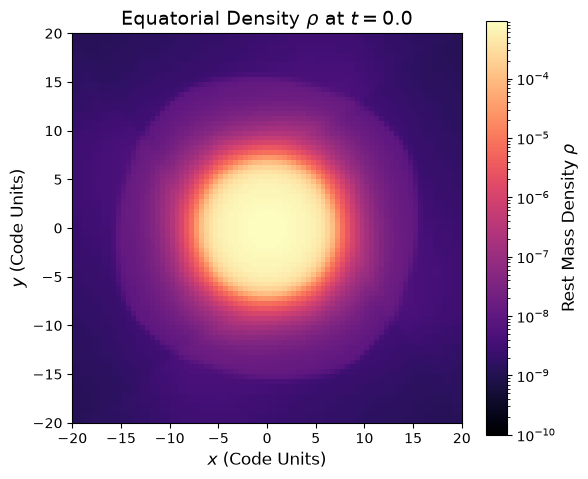

In [41]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Point Python to the official Athena++ reader script
sys.path.append('/home/mi58rip/gr-athena/vis/python')
import athena_read

filepath = '/home/mi58rip/gr-athena/runs/rns_test_SFHo/outputs/test_SMR/gr_rns.out3.00169.athdf'

# 1. Correct Cartesian geometry functions matching the athena_read.py API
# face_func requires 4 arguments: xmin, xmax, ratio, and number of points
f_func = lambda xmin, xmax, xrat, nx: np.linspace(xmin, xmax, nx)

# center_func requires 2 arguments: left face (xm) and right face (xp)
c_func = lambda xm, xp: 0.5 * (xm + xp)

# vol_func requires 6 arguments: the min and max faces for all 3 dimensions
v_func = lambda x1m, x1p, x2m, x2p, x3m, x3p: (x1p - x1m) * (x2p - x2m) * (x3p - x3m)

# 2. Extract and stitch SMR data (Setting level=5 forces the highest resolution)
data = athena_read.athdf(
    filepath, 
    quantities=['hydro.prim.rho'],  # Use 'hydro.prim.rho' if your specific fork requires it
    level=5, 
    vol_func=v_func,
    face_func_1=f_func,
    face_func_2=f_func,
    face_func_3=f_func,
    center_func_1=c_func,
    center_func_2=c_func,
    center_func_3=c_func
)

# 3. Find the index closest to z = 0 using cell-centered (v) coordinates
z_coords = data['x3v']
z_idx = np.argmin(np.abs(z_coords - 0.0))

# 4. Extract the 2D density array and face-centered (f) bounding coordinates
rho_equator = data['hydro.prim.rho'][z_idx, :, :]
x = data['x1f']
y = data['x2f']

# 5. Render the Plot
fig, ax = plt.subplots(figsize=(6, 5))

mesh = ax.pcolormesh(
    x, y, rho_equator, 
    cmap='magma', 
    norm=LogNorm(vmin=1e-10, vmax=rho_equator.max())
)

# Formatting
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label(r'Rest Mass Density $\rho$', fontsize=12)

ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)
ax.set_xlabel(r'$x$ (Code Units)', fontsize=12)
ax.set_ylabel(r'$y$ (Code Units)', fontsize=12)
ax.set_title(r'Equatorial Density $\rho$ at $t=0.0$', fontsize=14)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
sfho_eos_table_raw = '/home/mi58rip/gr-athena/eos_tables/SFHo.h5'
sfho_eos_table_appended_cold_slice_patched_ye = '/home/mi58rip/gr-athena/eos_tables/SFHo_with_cold_slice.h5'
sfho_eos_table_Tc0_100 = '/home/mi58rip/gr-athena/eos_tables/SFHo_Tc0.100/SFHo_Tc0.100.h5'

# Print the contents of the HDF5 file
# with h5py.File(sfho_eos_table_raw, 'r') as f:
#     print("Contents of the raw SFHo EOS table:")
#     f.visititems(print_hdf5_structure)

with h5py.File(sfho_eos_table_appended_cold_slice_patched_ye, 'r') as f:
    print("\nContents of the appended cold slice patched ye SFHo EOS table:")
    f.visititems(print_hdf5_structure)

# with h5py.File(sfho_eos_table_Tc0_100, 'r') as f:
#     print("\nContents of the Tc0.100 SFHo EOS table:")
#     f.visititems(print_hdf5_structure)